1: Dataset de Precios de Viviendas (Regresión)

1: Importación de librerías y carga de datos

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 1. Carga del archivo CSV original
csv_path = r"C:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\data\data_original\house_pricing\house_pricing.csv"
df_house = pd.read_csv(csv_path)


# IMPORTANTE: Filtramos el dataset para quedarnos únicamente con los datos etiquetados
# Eliminando las filas destinadas al 'leaderboard' (indicación expresa del PDF)
df_house = df_house[df_house['Split'] == 'labeled']
print(f"Dimensiones iniciales del dataset: {df_house.shape}")

# 2. Identificación y renombrado de la variable objetivo
target_column_name = 'SalePrice'
df_house.rename(columns={target_column_name: 'target'}, inplace=True)

# 3. Limpieza crítica: Eliminar nulos en el target (Requisito del PDF)
df_house = df_house.dropna(subset=['target'])

# 4. Eliminación de columnas no útiles o duplicadas mal escritas
# Eliminamos 'Id' (no aporta valor predictivo) y 'Electtrical' (columna corrupta/duplicada)
columns_to_drop = ['Id', 'Electtrical']
# Validamos que existan en el DataFrame antes de borrarlas para evitar errores
columns_to_drop = [col for col in columns_to_drop if col in df_house.columns]
df_house.drop(columns=columns_to_drop, inplace=True)
print(f"Columnas innecesarias eliminadas: {columns_to_drop}")

# 5. Tratamiento de valores nulos (Imputación de datos faltantes)
# Separamos las columnas por tipo de dato para aplicar la estrategia correcta
numeric_cols = df_house.select_dtypes(include=[np.number]).columns.drop('target')
categorical_cols = df_house.select_dtypes(include=['object']).columns

# Imputamos variables numéricas con la mediana
for col in numeric_cols:
    if df_house[col].isnull().any():
        median_value = df_house[col].median()
        df_house[col] = df_house[col].fillna(median_value)

# Imputamos variables categóricas con la moda (el valor más frecuente)
for col in categorical_cols:
    if df_house[col].isnull().any():
        mode_value = df_house[col].mode()[0]
        df_house[col] = df_house[col].fillna(mode_value)

print(f"Valores nulos restantes en el dataset: {df_house.isnull().sum().sum()}")
print(f"Dimensiones finales del dataset limpio: {df_house.shape}")

Dimensiones iniciales del dataset: (794, 37)
Columnas innecesarias eliminadas: ['Id', 'Electtrical']
Valores nulos restantes en el dataset: 0
Dimensiones finales del dataset limpio: (794, 35)


C:\Users\Alumne_mati1\AppData\Local\Temp\ipykernel_9308\3024176162.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_house.select_dtypes(include=['object']).columns


2: Selección de características (Feature Selection) con Random Forest

In [2]:
# Separamos las variables predictoras (features) de la variable objetivo (target)
X_house = df_house.drop(columns=['target'])
y_house = df_house['target']

# Convertimos variables categóricas (texto) a numéricas usando One-Hot Encoding si existen
X_house = pd.get_dummies(X_house, drop_first=True)

# Entrenamos un Random Forest para evaluar la importancia real de cada variable
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=42)
rf_regressor.fit(X_house, y_house)

# Instrucción del documento: Seleccionar un subconjunto de las 4 o 5 características más importantes para evitar ruido [cite: 5, 6, 7]
importances = pd.Series(rf_regressor.feature_importances_, index=X_house.columns)
top_features = importances.nlargest(5).index.tolist()

print("Las 5 características principales seleccionadas por Random Forest:", top_features)

# Filtramos las columnas del dataset para quedarnos únicamente con las seleccionadas
X_house_filtered = X_house[top_features]

Las 5 características principales seleccionadas por Random Forest: ['YearBuilt', 'GarageCars', 'GrLivArea', 'GarageArea', '1stFlrSF']


3: División y Escalado de datos

In [3]:
# Dividimos el conjunto filtrado en datos de entrenamiento (80%) y prueba (20%)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house_filtered, y_house, test_size=0.2, random_state=42
)

# Creamos y aplicamos el escalador Z-score para mejorar la convergencia de la Red Neuronal
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

print(f"Datos de entrenamiento listos. Dimensiones: {X_train_h_scaled.shape}")

Datos de entrenamiento listos. Dimensiones: (635, 5)


4: Construcción y entrenamiento de la Red Neuronal (FNN)

In [6]:
# CADA VEZ QUE EJECUTAS ESTA CELDA, EL MODELO SE BORRA Y VUELVE A EMPEZAR DESDE CERO

# 1. Volvemos a instanciar la arquitectura para inicializar los pesos aleatoriamente
house_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_h_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1) 
])

# 2. Definimos el optimizador con la tasa de aprendizaje ajustada
custom_optimizer = keras.optimizers.Adam(learning_rate=0.01)

# 3. Compilamos el modelo con los parámetros limpios
# Compilamos definiendo el optimizador Adam y la función de pérdida MSE
#house_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
house_model.compile(optimizer=custom_optimizer, loss='mse', metrics=['mae'])

print("¡Modelo inicializado desde cero y compilado correctamente!")

¡Modelo inicializado desde cero y compilado correctamente!


In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

# Al ejecutar esta celda inmediatamente después de la Celda anterior, arrancará sin memoria previa


# 1. Configuramos el Early Stopping para que vigile el val_loss
# Si el val_loss no mejora durante 10 épocas consecutivas (patience), detiene el entrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Iniciando el entrenamiento con Early Stopping y subconjunto óptimo de features...")
history_house = house_model.fit(
    X_train_h_scaled, y_train_h, 
    validation_split=0.2, 
    epochs=200, 
    batch_size=32, 
    callbacks=[early_stop], # Agregamos el callback aquí
    verbose=1
)

Iniciando el entrenamiento con Early Stopping y subconjunto óptimo de features...
Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 29365725184.0000 - mae: 163074.2031 - val_loss: 27475335168.0000 - val_mae: 157024.6875
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29350858752.0000 - mae: 163032.5156 - val_loss: 27443120128.0000 - val_mae: 156935.7188
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29282396160.0000 - mae: 162848.7500 - val_loss: 27332126720.0000 - val_mae: 156633.0625
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29087262720.0000 - mae: 162338.0625 - val_loss: 27054800896.0000 - val_mae: 155880.6094
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28663363584.0000 - mae: 161210.1094 - val_loss: 26503989248.0000 - val_mae: 154377.3281
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27890356224.0000 - mae: 159136.5781 - val_loss: 25575055360.0000 - val_mae: 151804.9844
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━

Gráfico

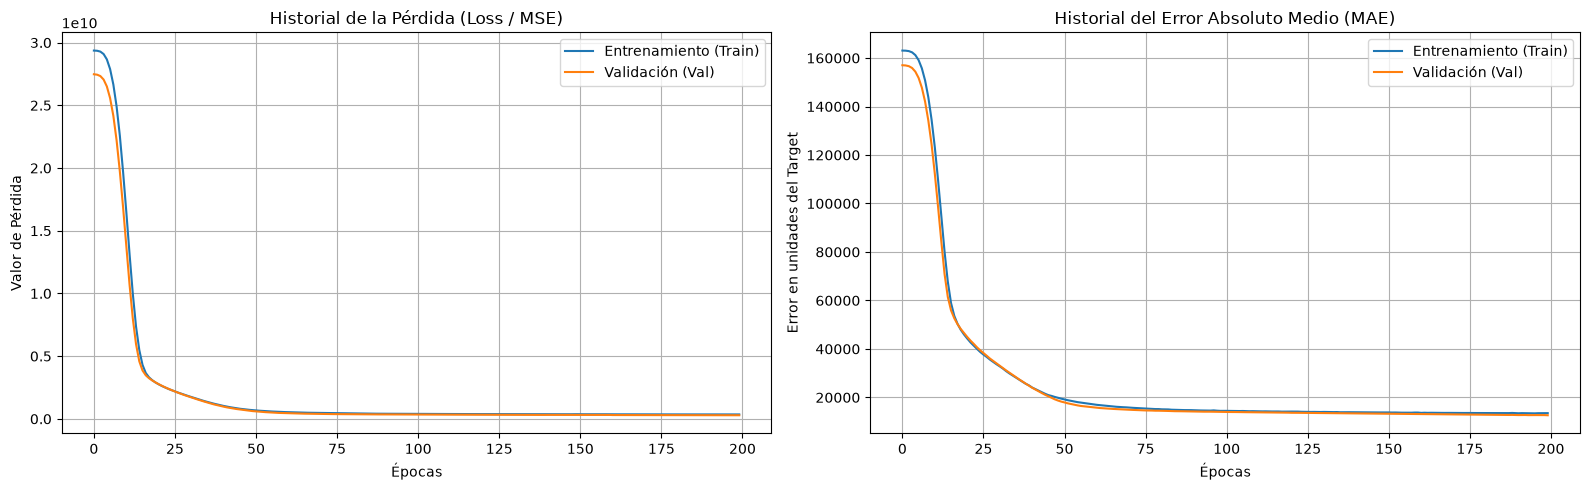

In [9]:
import matplotlib.pyplot as plt

history = history_house

# 1. Crear la figura con dos subgráficos (uno para Loss y otro para MAE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 2. Gráfico de la Función de Pérdida (Loss / MSE)
ax1.plot(history.history['loss'], label='Entrenamiento (Train)')
ax1.plot(history.history['val_loss'], label='Validación (Val)')
ax1.set_title('Historial de la Pérdida (Loss / MSE)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Valor de Pérdida')
ax1.legend()
ax1.grid(True)

# 3. Gráfico del Error Absoluto Medio (MAE)
ax2.plot(history.history['mae'], label='Entrenamiento (Train)')
ax2.plot(history.history['val_mae'], label='Validación (Val)')
ax2.set_title('Historial del Error Absoluto Medio (MAE)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Error en unidades del Target')
ax2.legend()
ax2.grid(True)

# Mostrar los gráficos
plt.tight_layout()
plt.show()